## EJERCICIO ##

# Fase 1: Exploración

1.1 Exploración inicial de los datos para identificar problemas (nulos, duplicados, columnas disponibles, tipos de datos)
1.2 Utiliza funciones de Pandas para obtener información sobre la estructura de los datos, la presencia de valores nulos y estadísticas básicas de las columnas involucradas.
1.3 Une los dos conjuntos de datos de la forma más eficiente.

In [ ]:
## Importo las librerias que necesito ##

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# Transformo los archivos en dataframes

df_flight_activity = pd.read_csv('Customer Flight Activity.csv', index_col=0)
df_loyalty_history = pd.read_csv('Customer Loyalty History.csv', index_col=0)

In [45]:
# Visualizo el contenido de los dataframes

df_flight_activity.head()

,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
Loyalty Number,,,,,,,,,
100018,2017,1,3,0,3,1521,152.0,0,0
100102,2017,1,10,4,14,2030,203.0,0,0
100140,2017,1,6,0,6,1200,120.0,0,0
100214,2017,1,0,0,0,0,0.0,0,0
100272,2017,1,0,0,0,0,0.0,0,0


In [46]:
df_loyalty_history.head()

,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
Loyalty Number,,,,,,,,,,,,,,,
480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [ ]:
## Validación de datos ##

# Identifico las variables o columnas disponibles en cada dataframe

df_flight_activity.info()

# Análisis:
# - no hay valores nulos
# - Points Accumulated es un tipo de dato float64 -> hay que convertirlo a int64 para uniformarlo con Points Redeemed

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [ ]:
df_loyalty_history.info()

# Análisis:
# - las categorias Salary, Cancellation Year y Cancellation Month contienen valores nulos
# - Cancellation Year y Cancellation Month son de tipo de dato float -> hay que uniformarlos a int64

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

# 1.2 Limpieza de Datos:
- Elimina o trata los valores nulos, si los hay, en las columnas clave para asegurar que los datos estén completos.
- Verifica la consistencia y corrección de los datos para asegurarte de que los datos se presenten de forma coherente.
- Realiza cualquier ajuste o conversión necesaria en las columnas (por ejemplo, cambiar tipos de datos) para garantizar la adecuación de los datos para el análisis estadístico.

In [ ]:
df_loyalty_history.isnull().sum()

# Análisis:
# - Confirmo la cantidad de nulos de las categorias Salary, Cancellation Year y Cancellation Month
# - Salary, Cancellation Year y Cancellation Month son variables numéricas

Loyalty Number            0
Country                   0
Province                  0
City                      0
Postal Code               0
Gender                    0
Education                 0
Salary                 4238
Marital Status            0
Loyalty Card              0
CLV                       0
Enrollment Type           0
Enrollment Year           0
Enrollment Month          0
Cancellation Year     14670
Cancellation Month    14670
dtype: int64

In [ ]:
# Calculo el % de nulos de cada categoría para ver como gestionarlos

nulos = df_loyalty_history.isnull().sum() / df_loyalty_history.shape[0] * 100
nulos = nulos[nulos > 0].round(0)
nulos.sort_values(ascending=False)

# Análisis:
# - los % de nulos representan más de un 20%
# - los nulos de Cancellation Year + Month pueden significar que el cliente sigue activo dentro del programa de lealtad -> no lo puedo reemplazar a texto (por ej. "active") porque es un dato numérico
# - los nulos de Salary pueden deberse a que los clientes no han querido compartir esta información -> no lo puedo reemplazar a texto (por ej. "active") porque es un dato numérico


Cancellation Year     88.0
Cancellation Month    88.0
Salary                25.0
dtype: float64

In [ ]:
# Reviso los duplicados

df_flight_activity.duplicated().sum()

# Análisis:
# - hay 1864 filas duplicadas


np.int64(1864)

In [ ]:
# Visualizo las filas duplicadas para ver qué arrojan y si las puedo eliminar

df_flight_activity[df_flight_activity["Loyalty Number"].duplicated(keep=False)].sort_values("Loyalty Number").head(20)

# Análisis:
# - no puedo eliminarlas ya que corresponden a distintos vuelos realizados en diferentes meses por un mismo cliente

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
388723,100018,2018,12,17,6,23,4945,494.0,0,0
185911,100018,2017,12,6,0,6,1908,190.0,0,0
101406,100018,2017,7,10,0,10,3870,387.0,0,0
287317,100018,2018,6,0,0,0,0,0.0,0,0
169010,100018,2017,11,13,1,14,3374,337.0,0,0
46353,100018,2018,10,6,4,10,3110,311.0,385,31
304218,100018,2018,7,9,7,16,2736,273.0,0,0
16901,100018,2017,2,2,2,4,1320,132.0,0,0
213311,100018,2017,3,14,3,17,2533,253.0,438,36


In [ ]:
df_loyalty_history.duplicated().sum()

# Análisis:
# - no hay filas duplicadas

np.int64(0)

In [28]:
# Uno los 2 conjuntos de datos en un mismo dataframe

df_final = df_loyalty_history.merge(df_flight_activity, on=['Loyalty Number'], how='left')

In [29]:
df_final.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,...,Cancellation Month,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,NaN,2017,1,0,0,0,0,0.0,0,0
1,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,NaN,2017,2,3,0,3,2823,282.0,0,0
2,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,NaN,2017,3,0,0,0,0,0.0,0,0
3,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,NaN,2017,4,0,0,0,0,0.0,0,0
4,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,...,NaN,2018,10,6,2,8,3352,335.0,465,38


In [42]:
df_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Country                      405624 non-null  str    
 2   Province                     405624 non-null  str    
 3   City                         405624 non-null  str    
 4   Postal Code                  405624 non-null  str    
 5   Gender                       405624 non-null  str    
 6   Education                    405624 non-null  str    
 7   Salary                       302952 non-null  float64
 8   Marital Status               405624 non-null  str    
 9   Loyalty Card                 405624 non-null  str    
 10  CLV                          405624 non-null  float64
 11  Enrollment Type              405624 non-null  str    
 12  Enrollment Year              405624 non-null  int64  
 13  Enrollment

In [ ]:
# Convierto las columnas "Cancellation Year" y "Cancellation Month" a Int64 que guarda números enteros pero también permite valores faltantes (
# Convierto la columna "Points Accumulated" a int64

df_final["Points Accumulated"] = df_final["Points Accumulated"].astype("int64")
df_final.dtypes

Loyalty Number                   int64
Country                            str
Province                           str
City                               str
Postal Code                        str
Gender                             str
Education                          str
Salary                         float64
Marital Status                     str
Loyalty Card                       str
CLV                            float64
Enrollment Type                    str
Enrollment Year                  int64
Enrollment Month                 int64
Cancellation Year                Int64
Cancellation Month               Int64
Year                             int64
Month                            int64
Flights Booked                   int64
Flights with Companions          int64
Total Flights                    int64
Distance                         int64
Points Accumulated               int64
Points Redeemed                  int64
Dollar Cost Points Redeemed      int64
dtype: object

# Fase 2: Análisis Estadístico
1. Análisis de variables numéricas:
1.1 Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables numéricas relevantes.
1.2 Identificación de valores atípicos en las variables numéricas.
1.3 Análisis de correlación entre variables numéricas
2. Análisis de variables categóricas:
2.1 Distribución de frecuencias de las variables categóricas relevantes.

In [ ]:
# 1.1 Estadísticas descriptivas de las variables numéricas relevantes
# 1.2 Identificación de valores atípicos en las variables numéricas

# - Media
# - Mediana
# - Moda
# - Desviación estándar
# - Varianza
# - Valor mínimo, valor máximo y rango
# - IQR


In [ ]:
# Variables numéricas relevantes

# Tomo 2 variables como relvantes para el análisis:

# 1. Salary
# 2. CLV (Customer Lifetime Value)

# 1. Salary
media_salary = df_final['Salary'].mean()
mediana_salary = df_final['Salary'].median()
moda_salary = df_final['Salary'].mode()[0]
desv_salary = df_final['Salary'].std()
var_salary = df_final['Salary'].var()
min_salary = df_final['Salary'].min()
max_salary = df_final['Salary'].max()
rango = df_final['Salary'].max() - df_final['Salary'].min()

print(np.round(media_salary,1))
print(np.round(mediana_salary,1))
print(np.round(moda_salary,1))
print(np.round(desv_salary,1))
print(np.round(var_salary,1))
print(np.round(min_salary,1))
print(np.round(max_salary,1))
print(rango)

# Análisis:
# - Media y mediana son muy parecidas, lo cual significa que los datos están distribuidos de manera equilibrada alrededor del centro
# - La moda (101933) nos arroja el valor que aparece más veces en el conjunto de datos, lo cual es un 29% superior a la media
# - La varianza es muy elevada (1224449407.5) lo cual indica que los salarios presentan una gran dispersión respecto a la media
# - El valor mínimo es -58486 lo cual arroja un posible error de captura del valor en cuestión
# - La presencia de este valor negativo incrementa considerablemente el rango (diferencia entre el valor máximo y el mínimo)


79268.8
73479.0
101933.0
34992.1
1224449407.5
-58486.0
407228.0
465714.0


In [ ]:
# IQR

Q1 = df_final['Salary'].quantile(0.25)
Q3 = df_final['Salary'].quantile(0.75)
IQR = Q3 - Q1

# Detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers = df_final[(df_final['Salary'] < limite_inferior) | (df_final['Salary'] > limite_superior)]

print(f"IQR: {IQR:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")

# Análisis:
# - Los outliers representan un 4.4% de todos los datasets, lo cual indica una muestra de datos homogenea (outliers: 13320 / total datasets: 302952)


IQR: 29350.00
Límite inferior: 15237.00
Límite superior: 132637.00
Número de outliers detectados: 13320


In [ ]:
# 2. CLV (Customer Lifetime Value)

media_clv = df_final['CLV'].mean()
mediana_clv = df_final['CLV'].median()
moda_clv = df_final['CLV'].mode()[0]
desv_clv = df_final['CLV'].std()
var_clv = df_final['CLV'].var()
min_clv = df_final['CLV'].min()
max_clv = df_final['CLV'].max()
rango = df_final['CLV'].max() - df_final['CLV'].min()

print(np.round(media_clv,1))
print(np.round(mediana_clv,1))
print(np.round(moda_clv,1))
print(np.round(desv_clv,1))
print(np.round(var_clv,1))
print(np.round(min_clv,1))
print(np.round(max_clv,1))
print(np.round(rango,1))

# Análisis:
# - La media es relativamente más alta de la mediana, lo cual significa que hay valores muy altos que la empujan hacia arriba (sesgo positivo)
# - La mayoría de los registros tienen valores relativamente bajos
# - La desviación estándar es bastante elevada (casi el 86 % de la media), lo que indica una variabilidad importante
# - También la diferencia entre valor mínimo y máximo es muy elevada e indica que los valores abarcan un intervalo muy grande

7992.0
5776.3
3873.6
6863.7
47109881.5
1898.0
83325.4
81427.4


In [ ]:
# IQR

Q1_IQR = df_final['CLV'].quantile(0.25)
Q3_IQR = df_final['CLV'].quantile(0.75)
IQR_CLV = Q3_IQR - Q1_IQR

# Detectar outliers
limite_inferior_CLV = Q1 - 1.5 * IQR
limite_superior_CLV = Q3 + 1.5 * IQR
outliers = df_final[(df_final['CLV'] < limite_inferior) | (df_final['CLV'] > limite_superior)]

print(f"IQR: {IQR_CLV:.2f}")
print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")
print(f"Número de outliers detectados: {len(outliers)}")

# Análisis:
# - Los outliers representan la gran mayoría de los datos (89.8%) (outliers: 364224 / total datasets: 405624), lo cual confirma una variabilidad importante

IQR: 4951.50
Límite inferior: 15237.00
Límite superior: 132637.00
Número de outliers detectados: 364224


- Distribución de frecuencias de las variables categóricas relevantes.

In [ ]:
# 1.3 Análisis de correlación entre variables numéricas
# --> La correlación indica cómo cambian dos variables entre sí

# Importo recursos / librerías
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

<Axes: >

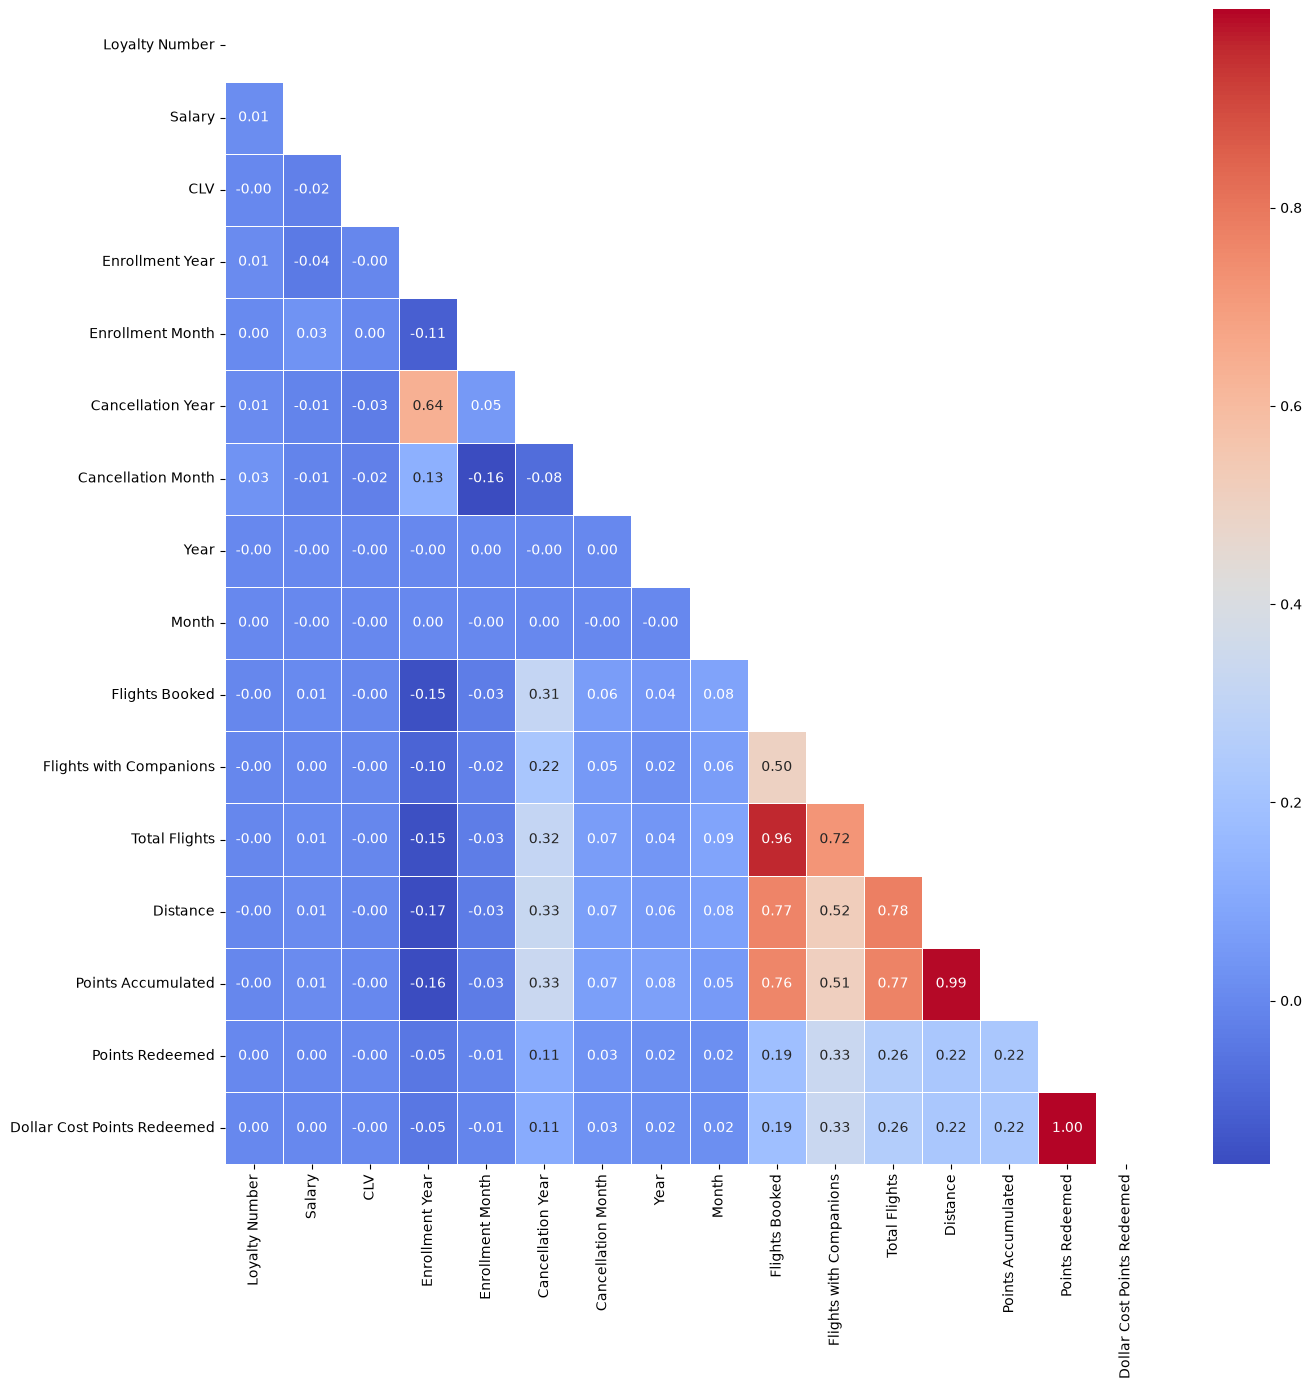

In [ ]:
# Creo una matriz de correlacion para visualizar la análisis
# Selecciono el método "pearson" y únicamente las columnas de tipo numérico (include="number")

correlation_matrix = df_final.select_dtypes(include="number").corr(method="pearson")
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(15, 15))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f',mask = mask, linewidths=.5)

# Premisas:
# - Por defecto, corr() excluye los valores NaN

# Análisis:
# - 3 son las variables que presentan una correlación positiva fuerte (cercana a 1):
# 1. Total Flights vs Flights Booked:
# 2. Points Accumulated vs Distance
# 3. Points Redeemed vs Dollar Cost Points Redeemed

In [ ]:
# 2. Análisis de variables categóricas: Distribución de frecuencias de las variables categóricas relevantes.

# Tomo las siguientes variables categóricas:

# 1. Country
# 2. Gender
# 3. Loyalty Card
# 4. Education

# 1. Country
frecuencia_absoluta = df_final['Country'].value_counts()

frecuencia_relativa = (
    df_final['Country'].value_counts(normalize=True) * 100
).round(2)

tabla_frecuencias = pd.DataFrame({
    'Country': frecuencia_absoluta.index,
    'Frecuencia absoluta': frecuencia_absoluta.values,
    'Frecuencia relativa (%)': frecuencia_relativa.values
})

tabla_frecuencias

# Análisis:
# - El 100% de la muestra son clientes de Canadá


,Country,Frecuencia absoluta,Frecuencia relativa (%)
0,Canada,405624,100.0


In [ ]:
# 2. Gender
frecuencia_absoluta_gender = df_final['Gender'].value_counts()

frecuencia_relativa_gender = (
    df_final['Gender'].value_counts(normalize=True) * 100
).round(2)

tabla_frecuencias = pd.DataFrame({
    'Gender': frecuencia_absoluta_gender.index,
    'Frecuencia absoluta': frecuencia_absoluta_gender.values,
    'Frecuencia relativa (%)': frecuencia_relativa_gender.values
})

tabla_frecuencias

# Análisis:
# - La distribución de género está bastante equilibrada en un 50-50%


,Gender,Frecuencia absoluta,Frecuencia relativa (%)
0,Female,203640,50.2
1,Male,201984,49.8


In [ ]:
# 3. Loyalty Card
frecuencia_absoluta_loyalty = df_final['Loyalty Card'].value_counts()

frecuencia_relativa_loyalty = (
    df_final['Loyalty Card'].value_counts(normalize=True) * 100
).round(2)

tabla_frecuencias = pd.DataFrame({
    'Loyalty Card': frecuencia_absoluta_loyalty.index,
    'Frecuencia absoluta': frecuencia_absoluta_loyalty.values,
    'Frecuencia relativa (%)': frecuencia_relativa_loyalty.values
})

tabla_frecuencias

# Análisis:
# - El tipo de loyalty card "Star" representa la mayoría con un 45%, seguido por "Nova"(34%) y "Aurora" (21%)

,Loyalty Card,Frecuencia absoluta,Frecuencia relativa (%)
0,Star,184224,45.42
1,Nova,137568,33.92
2,Aurora,83832,20.67


In [ ]:
# 4. Education
frecuencia_absoluta_edu = df_final['Education'].value_counts()

frecuencia_relativa_edu = (
    df_final['Education'].value_counts(normalize=True) * 100
).round(2)

tabla_frecuencias_edu = pd.DataFrame({
    'Education': frecuencia_absoluta_edu.index,
    'Frecuencia absoluta': frecuencia_absoluta_edu.values,
    'Frecuencia relativa (%)': frecuencia_relativa_edu.values
})

tabla_frecuencias_edu

# Análisis:
# - La gran mayoría (62%) de los clientes cuentan con un bachelor como títolo de estduio


,Education,Frecuencia absoluta,Frecuencia relativa (%)
0,Bachelor,253752,62.56
1,College,102672,25.31
2,High School or Below,19008,4.69
3,Doctor,17856,4.40
4,Master,12336,3.04


# Fase 3 - Visualización

3.1 ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?
3.2 ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los clientes?
3.3 ¿Cuál es la distribución de los clientes por provincia o estado?
3.4 ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?
3.5 ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?
3.6 ¿Cómo se distribuyen los clientes según su estado civil y género?

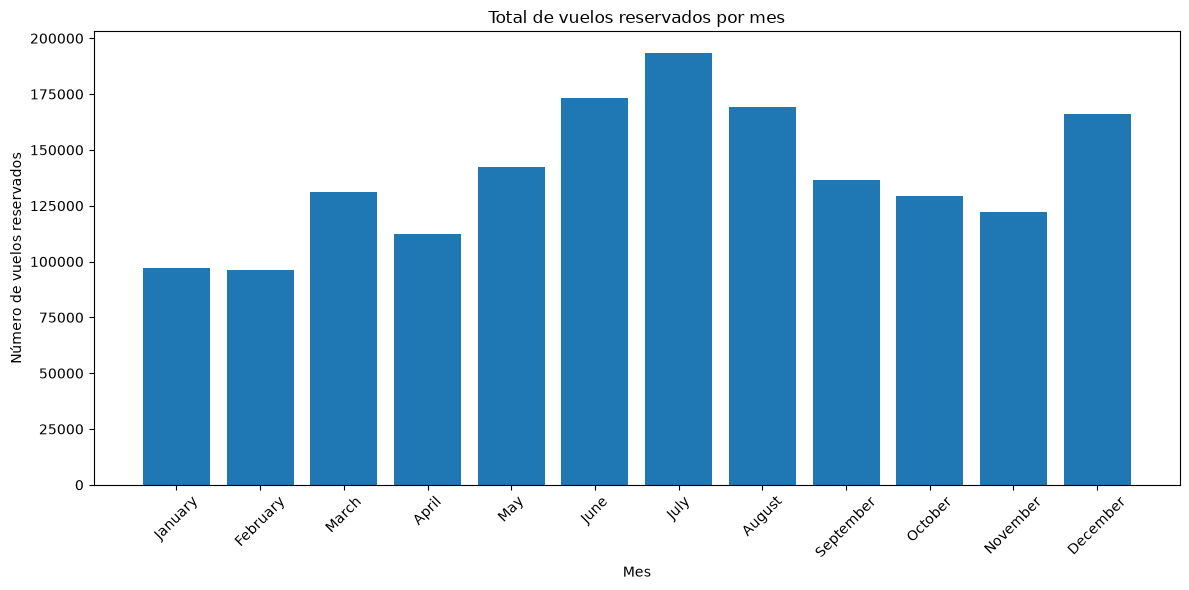

In [ ]:
# 3.1 ¿Cómo se distribuye la cantidad de vuelos reservados por mes durante el año?

import calendar
import matplotlib.pyplot as plt

# Agrupar vuelos por mes
vuelos_mes = df_final.groupby("Month")["Flights Booked"].sum()

# Obtener el nombre de los meses
meses = [calendar.month_name[m] for m in vuelos_mes.index]

# Crear gráfico
plt.figure(figsize=(12, 6))
plt.bar(meses, vuelos_mes.values)

plt.title("Total de vuelos reservados por mes")
plt.xlabel("Mes")
plt.ylabel("Número de vuelos reservados")

# Girar las etiquetas para que no se solapen
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Análisis:
# - El verano (julio seguido por junio y agosto) y diciembre son los meses que arrojan la mayor cantidad de vuelos reservados


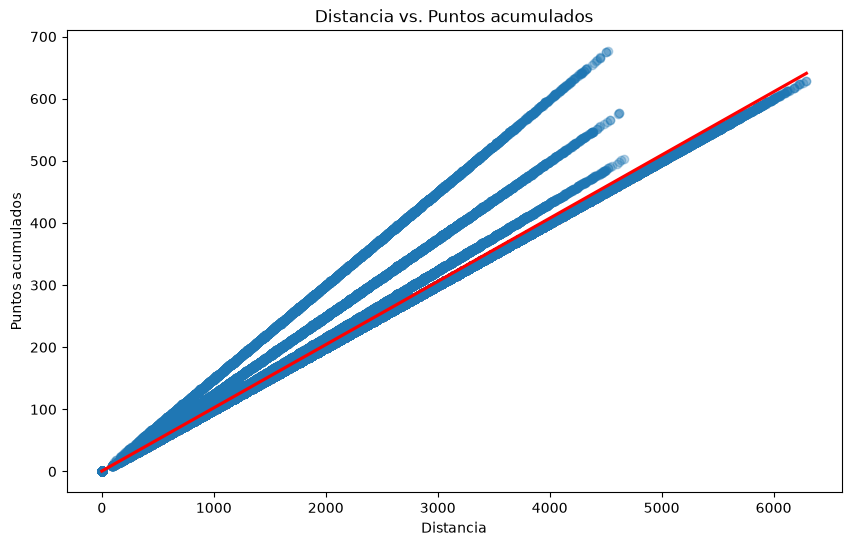

In [ ]:
# 3.2 ¿Existe una relación entre la distancia de los vuelos y los puntos acumulados por los cliente?

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_final,
    x="Distance",
    y="Points Accumulated",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Distancia vs. Puntos acumulados")
plt.xlabel("Distancia")
plt.ylabel("Puntos acumulados")

plt.show()

# Análisis:
# - Sí, a mayor distancia una mayor cantidad de puntos acumulados (visible también en el heatmap anterior)


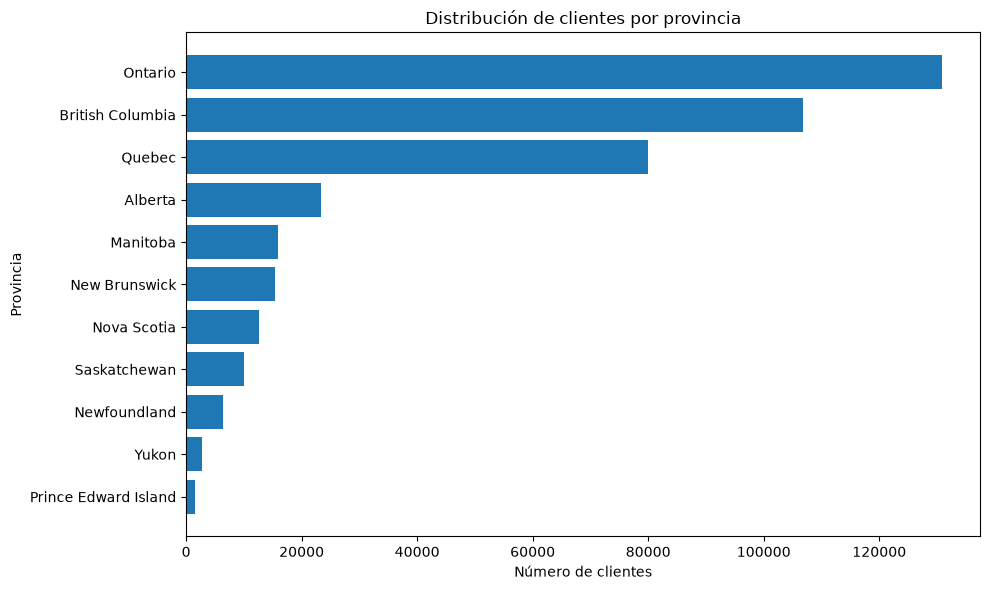

In [ ]:
# 3.3 ¿Cuál es la distribución de los clientes por provincia o estado?

clientes_provincia = df_final["Province"].value_counts()

plt.figure(figsize=(10, 6))

plt.barh(clientes_provincia.index, clientes_provincia.values)

plt.title("Distribución de clientes por provincia")
plt.xlabel("Número de clientes")
plt.ylabel("Provincia")

# Invierte el eje Y para que la provincia con más clientes aparezca arriba
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# Análisis:
# - Ontario es la provincia que concentra el mayor # de clientes

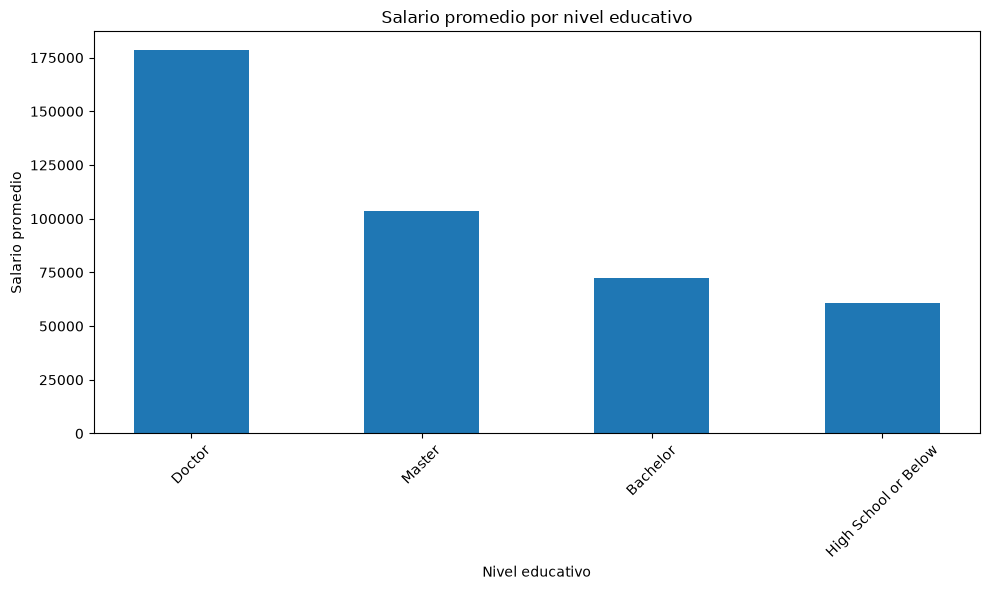

In [ ]:
# 3.4 ¿Cómo se compara el salario promedio entre los diferentes niveles educativos de los clientes?

plt.figure(figsize=(10, 6))

plt.bar(
    salario_medio.index,
    salario_medio.values,
    width=0.5   # Valor por defecto ≈ 0.8
)

plt.title("Salario promedio por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario promedio")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Análisis:
# - A mayor nivel educativo mayor salario promedio

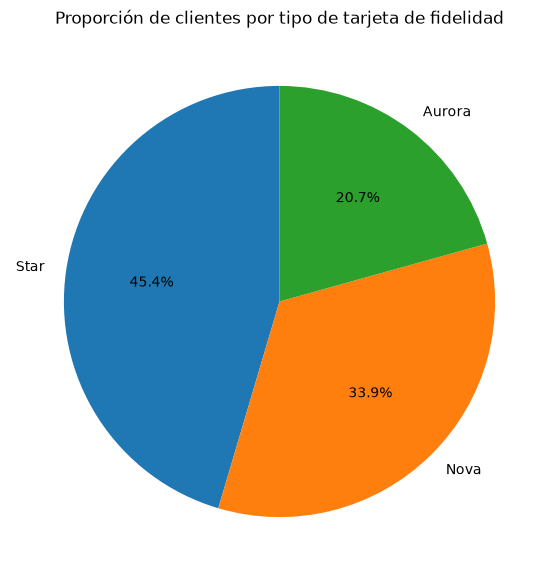

In [ ]:
# 3.5 ¿Cuál es la proporción de clientes con diferentes tipos de tarjetas de fidelidad?

# Calcular la proporción de cada tipo de tarjeta
tarjetas = df_final["Loyalty Card"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    tarjetas.values,
    labels=tarjetas.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proporción de clientes por tipo de tarjeta de fidelidad")

plt.show()

# Análisis:
# - El tipo de loyalty card "Star" representa la mayoría con un 45%, seguido por "Nova"(34%) y "Aurora" (21%)

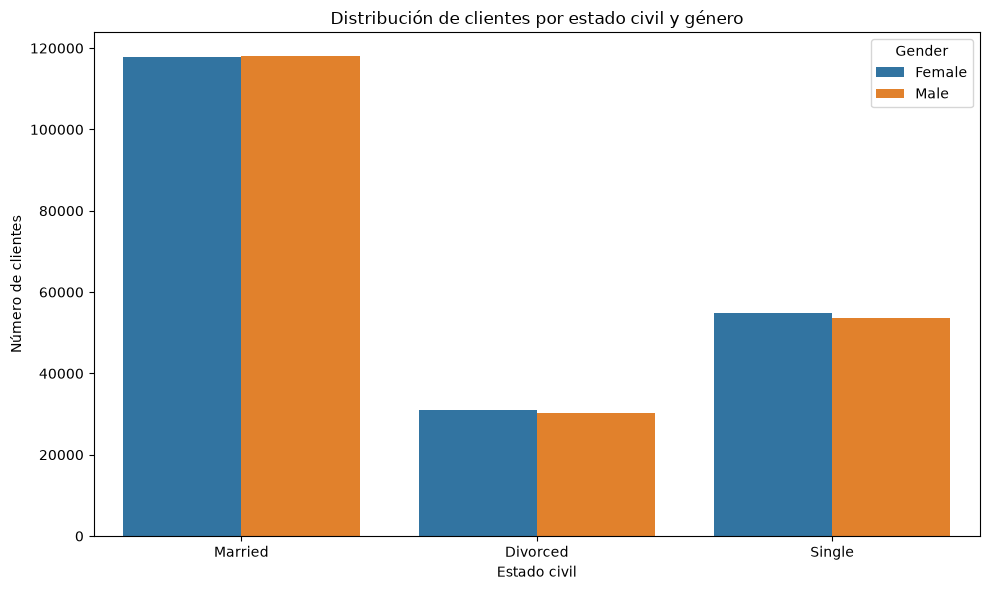

In [ ]:
# 3.6 ¿Cómo se distribuyen los clientes según su estado civil y género?

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_final,
    x="Marital Status",
    hue="Gender"
)

plt.title("Distribución de clientes por estado civil y género")
plt.xlabel("Estado civil")
plt.ylabel("Número de clientes")

plt.tight_layout()
plt.show()

# Análisis:
# - La distribución de clientes por estado civil y género es muy equilibrada

# Fase 4 - Evaluación de Diferencias en Reservas de Vuelos por Nivel Educativo

Utilizando un conjunto de datos que hemos compartido, se busca evaluar si existen diferencias significativas en el número de vuelos reservados según el nivel educativo de los clientes. Para ello, los pasos que deberás seguir son:
1. Preparación de Datos: Filtra el conjunto de datos para incluir únicamente las columnas relevantes: 'Flights Booked' y 'Education'.
2. Análisis Descriptivo: Agrupa los datos por nivel educativo y calcula estadísticas descriptivas básicas (como el promedio, la desviación estándar) del número de vuelos reservados para cada grupo.

In [115]:
# 1. Preparación de Datos: Filtra el conjunto de datos para incluir únicamente las columnas relevantes: 'Flights Booked' y 'Education'.

df_education = df_final[["Flights Booked", "Education"]].dropna()
df_education.head()

,Flights Booked,Education
0,0,Bachelor
1,3,Bachelor
2,0,Bachelor
3,0,Bachelor
4,6,Bachelor


In [ ]:
# 2. Análisis Descriptivo

estadisticas = (
    df_education
    .groupby("Education")["Flights Booked"]
    .agg(
        media="mean",
        desviacion_estandar="std",
        mediana="median",
        minimo="min",
        maximo="max",
        total_clientes="count"
    )
    .round(2)
)

# Añadir el porcentaje de clientes por nivel educativo
estadisticas["frecuencia_clientes (%)"] = (
    estadisticas["total_clientes"] /
    estadisticas["total_clientes"].sum() * 100
).round(2)

estadisticas

# Análisis:
# - Los clientes con master son el nivel educativo que arroja el mayor promedio de vuelos reservados (4.18) aun que la media es muy similar entre los diferentes niveles
# - La desviación estándar es prácticamente la misma en todos los grupos lo que indica una dispersión similar del número de vuelos reservados independientemente del nivel educativo.
# - La mediana en todos los grupos es 1, lo que significa que al menos el 50 % de los clientes reservó un vuelo o menos
# - La gran mayoría (62.6%) de los clientes cuentan con un nivel educativo de bachelor

,media,desviacion_estandar,mediana,minimo,maximo,total_clientes,frecuencia_clientes (%)
Education,,,,,,,
Bachelor,4.09,5.22,1.0,0,21,253752,62.56
College,4.15,5.24,1.0,0,21,102672,25.31
Doctor,4.15,5.25,1.0,0,21,17856,4.40
High School or Below,4.16,5.23,1.0,0,21,19008,4.69
Master,4.18,5.21,1.0,0,21,12336,3.04
